In [166]:
from __future__ import annotations

import abc
from dataclasses import dataclass, field, replace
from typing import Any, Dict, Mapping, Sequence, Tuple
import time
import jax
import jax.numpy as jnp
from jax import random

import tensorflow_probability.substrates.jax as tfp
tfd = tfp.distributions

Array = jax.Array


@dataclass(frozen=True)
class Prior(abc.ABC):
    """
    JAX-friendly prior base class that delegates all probability operations to
    a TFP-JAX distribution. Subclasses must implement `tfp_dist()`.
    """

    alias: Dict[str, str] = field(init=False)
    params: Dict[str, Array] = field(init=False)
    name: str = ""

    def __init__(self,
                 parnames: Sequence[str] = (),
                 
                 name: str = "",
                 **kwargs: Any):

        prior_params: Tuple[str, ...] = getattr(type(self), "prior_params", None)
        if prior_params is None:
            raise ValueError(
                f"{type(self).__name__} must define class attribute "
                "`prior_params = (\"param1\", \"param2\", ...)`."
            )

        if not parnames:
            parnames = prior_params

        if len(parnames) != len(prior_params):
            raise ValueError(
                f"parnames has length {len(parnames)} but prior_params has "
                f"length {len(prior_params)}"
            )

        alias = dict(zip(prior_params, parnames))

        params: Dict[str, Array] = {}
        for intrinsic, external in alias.items():
            if external in kwargs:
                params[intrinsic] = jnp.asarray(kwargs[external])

        object.__setattr__(self, "alias", alias)
        object.__setattr__(self, "params", params)
        object.__setattr__(self, "name", name)

    # ------------------------------------------------------------------
    # Representation
    # ------------------------------------------------------------------
    def __repr__(self) -> str:
        argstring = [f"{k}={v}" for k, v in self.params.items()]
        return f"{type(self).__name__}({', '.join(argstring)})"
    
    def __len__(self) -> int:
        prior_params = getattr(type(self), "prior_params", ())
        if not prior_params:
            return 1
        return int(max(jnp.size(self.params.get(k, jnp.array(1.0)))
                       for k in prior_params))
    

    # ------------------------------------------------------------------
    # Subclasses *must* provide a TFP distribution
    # ------------------------------------------------------------------
    @abc.abstractmethod
    def tfp_dist(self) -> tfd.Distribution:
        """
        Return a TFP-JAX distribution object built from `self.params`.

        Must be implemented by subclasses.
        """
        raise NotImplementedError
    
    # ------------------------------------------------------------------
    # Probability interface (delegates to TFP)
    # ------------------------------------------------------------------
    def logpdf(self, x: Array) -> Array:
        return self.tfp_dist().log_prob(x)

    def __call__(self, x: Array) -> Array:
        return self.logpdf(x)



    # ------------------------------------------------------------------
    # Sampling and transforms via TFP
    # ------------------------------------------------------------------
    def sample(self,
               key: jax.random.KeyArray,
               shape: Tuple[int, ...] | None = None) -> Array:
        return self._sample_impl(key, shape)

    def _sample_impl(self, key: jax.random.KeyArray, shape: Tuple[int, ...]) -> Array:
        return self.tfp_dist().sample(seed=key, sample_shape=shape)

    def unit_transform(self, x: Array) -> Array:
        return self._ppf(x)

    def inverse_unit_transform(self, x: Array) -> Array:
        return self._cdf(x)

    def _ppf(self, x: Array) -> Array:
        return self.tfp_dist().quantile(x)

    def _cdf(self, x: Array) -> Array:
        return self.tfp_dist().cdf(x)
    
    # ------------------------------------------------------------------
    # Auto-diff gradient
    # ------------------------------------------------------------------
    def gradient(self, theta: Array) -> Array:
        def logp(t: Array) -> Array:
            return self(t).sum()
        return jax.grad(logp)(theta)

In [229]:

class Uniform(Prior):
    """
    Uniform distribution on [low, high].
    """
    # Intrinsic parameter names:
    prior_params = ("low", "high")

    def tfp_dist(self) -> tfd.Distribution:
        low = self.params.get("low")
        high = self.params.get("high")
        return tfd.Uniform(low=low, high=high)
    
    @property
    def range(self):
        # Good plotting range is simply the interval itself
        return self.params["low"], self.params["high"]
    
    @property
    def bounds(self):
        # Hard support boundaries
        return self.params["low"], self.params["high"]
    
    def serialize(self):
        return {
            "type": "Uniform",
            "low": float(self.params["low"]),
            "high": float(self.params["high"]),
            "name": self.name,
        }
    

class TopHat(Uniform):
    """Uniform distribution between two bounds, renamed for backwards compatibility
    :param low:
        Minimum of the distribution

    :param high:
        Maximum of the distribution
    """


class Normal(Prior):
    """A simple gaussian prior.


    :param mean:
        Mean of the distribution

    :param sigma:
        Standard deviation of the distribution
    """
    prior_params = ['mean', 'sigma']
    
    
    def tfp_dist(self) -> tfd.Distribution:
        mean = self.params.get("mean")
        sigma = self.params.get("sigma")
        return tfd.Normal(loc=mean, scale=sigma)

    @property
    def scale(self):
        return self.params['sigma']

    @property
    def loc(self):
        return self.params['mean']

    @property
    def range(self):
        nsig = 4
        return (self.params['mean'] - nsig * self.params['sigma'],
                self.params['mean'] + nsig * self.params['sigma'])

    def bounds(self, **kwargs):
        return (-jnp.inf, jnp.inf)



class MultivariateNormalPrior(Prior):
    """
    Multivariate Gaussian prior using TFP-JAX.
    Intrinsic parameters:
      - mean   : vector (d,)
      - Sigma  : covariance matrix (d,d)
    """
    prior_params = ("mean", "Sigma")

    # ---------------------------------------------------------
    # Build TFP distribution
    # ---------------------------------------------------------
    def tfp_dist(self) -> tfd.Distribution:
        mean = self.params["mean"]
        Sigma = self.params["Sigma"]
        return tfd.MultivariateNormalFullCovariance(
            loc=mean,
            covariance_matrix=Sigma
        )

    # ---------------------------------------------------------
    # Plotting helpers
    # ---------------------------------------------------------
    @property
    def range(self):
        """
        Return mean ± 4σ along diagonal directions.
        Good for plotting marginal bands.
        """
        mu = self.params["mean"]
        Sigma = self.params["Sigma"]
        sigma_diag = jnp.sqrt(jnp.diag(Sigma))
        nsig = 4.0
        return mu - nsig * sigma_diag, mu + nsig * sigma_diag

    @property
    def bounds(self):
        """
        MVN has infinite support.
        """
        dim = self.params["mean"].shape[0]
        return (
            -jnp.inf * jnp.ones(dim),
            +jnp.inf * jnp.ones(dim)
        )

    # ---------------------------------------------------------
    # Sampling (TFP handles batching)
    # ---------------------------------------------------------
    def sample(self, key, shape=None):
        if shape is None:
            shape = ()  # draw 1 vector
        return self.tfp_dist().sample(seed=key, sample_shape=shape)

    # ---------------------------------------------------------
    # Unit transform: u in (0,1)^d → θ in R^d
    #
    # θ = μ + L @ z     where z = N^{-1}(u)
    # L = chol(Sigma)
    # ---------------------------------------------------------
    def unit_transform(self, u):
        # inverse CDF of standard normal
        z = tfd.Normal(0.0, 1.0).quantile(u)

        # Cholesky factor L where Sigma = L Lᵀ
        L = jnp.linalg.cholesky(self.params["Sigma"])

        # θ = μ + L @ z
        return self.params["mean"] + L @ z

    # ---------------------------------------------------------
    # Inverse unit transform: θ → u in (0,1)^d
    #
    # u_i = Phi( (L^{-1} (θ - μ))_i )
    #
    # MVN CDF itself is expensive; this gives dimension-wise transform.
    # ---------------------------------------------------------
    def inverse_unit_transform(self, theta):
        mu = self.params["mean"]
        Sigma = self.params["Sigma"]

        # L (Cholesky)
        L = jnp.linalg.cholesky(Sigma)

        # Solve L z = theta - mu
        z = jax.scipy.linalg.solve_triangular(L, theta - mu, lower=True)

        # Convert z to uniform using Φ(z)
        standard_normal = tfd.Normal(0.0, 1.0)
        return standard_normal.cdf(z)

    # ---------------------------------------------------------
    # Serialization
    # ---------------------------------------------------------
    def serialize(self):
        return {
            "type": "MultivariateNormalPrior",
            "mean": jnp.asarray(self.params["mean"]).tolist(),
            "Sigma": jnp.asarray(self.params["Sigma"]).tolist(),
            "name": self.name,
        }
    


class ClippedNormal(Prior):
    """A Gaussian prior clipped to some range.

    :param mean:
        Mean of the normal distribution

    :param sigma:
        Standard deviation of the normal distribution

    :param low:
        Minimum of the distribution

    :param high:
        Maximum of the distribution
    """
    prior_params = ['mean', 'sigma', 'low', 'high']
    def tfp_dist(self) -> tfd.Distribution:
        mean = self.params.get("mean")
        sigma = self.params.get("sigma")
        low = self.params.get("low")
        high = self.params.get("high")
        return tfd.TruncatedNormal(loc=mean, scale=sigma, low=low, high=high)
 
    @property
    def scale(self):
        return self.params['sigma']

    @property
    def loc(self):
        return self.params['mean']

    @property
    def range(self):
        return (self.params['low'], self.params['high'])

    @property
    def args(self):
        a = (self.params['low'] - self.params['mean']) / self.params['sigma']
        b = (self.params['high'] - self.params['mean']) / self.params['sigma']
        return [a, b]

    @property
    def bounds(self):
        # Hard support boundaries
        return self.params["low"], self.params["high"]
    



class LogNormal(Prior):
    """A log-normal prior, where the natural log of the variable is distributed
    normally.  Useful for parameters that cannot be less than zero.

    Note that ``LogNormal(np.exp(mode) / f) == LogNormal(np.exp(mode) * f)``
    and ``f = np.exp(sigma)`` corresponds to "one sigma" from the peak.

    :param mode:
        Natural log of the variable value at which the probability density is
        highest.

    :param sigma:
        Standard deviation of the distribution of the natural log of the
        variable.
    """
    prior_params = ['mode', 'sigma']
    def tfp_dist(self) -> tfd.Distribution:
        mode = self.params.get("mode")
        sigma = self.params.get("sigma")
        return tfd.LogNormal(loc=mode, scale=sigma)

    @property
    def args(self):
        return [self.params["sigma"]]

    @property
    def scale(self):
        return  jnp.exp(self.params["mode"] + self.params["sigma"]**2)

    @property
    def loc(self):
        return 0

    @property
    def range(self):
        nsig = 4
        return (jnp.exp(self.params['mode'] + (nsig * self.params['sigma'])),
                jnp.exp(self.params['mode'] - (nsig * self.params['sigma'])))

    def bounds(self, **kwargs):
        return (0, jnp.inf)
    


class StudentT(Prior):
    """A Student's T distribution

    :param mean:
        Mean of the distribution

    :param scale:
        Size of the distribution, analogous to the standard deviation

    :param df:
        Number of degrees of freedom
    """
    prior_params = ['mean', 'scale', 'df']
    def tfp_dist(self) -> tfd.Distribution:
        mean = self.params.get("mean")
        scale = self.params.get("scale")
        df = self.params.get("df")
        return tfd.StudentT(df=df, loc=mean, scale=scale)
    
    @property
    def args(self):
        return [self.params['df']]

    @property
    def scale(self):
        return self.params['scale']

    @property
    def loc(self):
        return self.params['mean']

    @property
    def range(self):
        return self.tfp_dist().quantile(jnp.array([0.0025, 0.9975]))

    def bounds(self, **kwargs):
        return (-jnp.inf, jnp.inf)


In [230]:
uni = TopHat(
    parnames=("low", "high"),  # external names
    low=0.0,
    high=5.0
)

normal = Normal(
    parnames=("mean", "sigma"),
    mean=0.0,
    sigma=1.0
)


mean = jnp.array([0.0, 0.0])
Sigma = jnp.array([[1.0, 0.5],
                   [0.5, 2.0]])

multi = MultivariateNormalPrior(
    parnames=("mean", "Sigma"),
    mean=mean,
    Sigma=Sigma
)


trunc = ClippedNormal(
    parnames=("mean", "sigma", "low", "high"),
    mean=-2.0,
    sigma=3.0,
    low=-3.0,
    high=2.0
)

lognormal = LogNormal(
    parnames=("mode", "sigma"),
    mode=0.0,
    sigma=0.5
)

student = StudentT(
    parnames=("mean", "scale", "df"),
    mean=0.0,
    scale=1.0,
    df=5.0
)

In [231]:
samples = uni.sample(random.PRNGKey(0), shape=(100000,))
samples_normal = normal.sample(random.PRNGKey(1), shape=(100000,))

samples_multi = multi.sample(random.PRNGKey(2), shape=(100000,))

samples_trunc = trunc.sample(random.PRNGKey(3), shape=(100000,))

samples_lognormal = lognormal.sample(random.PRNGKey(4), shape=(100000,))

samples_student = student.sample(random.PRNGKey(5), shape=(100000,))

/Users/amanda/opt/anaconda3/envs/phmc/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/Users/amanda/opt/anaconda3/envs/phmc/lib/python3.10/site-packages/tensorflow_probability/python/internal/backend/jax/ops.py:342: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return np.array(value, dtype=dtype)
/Users/amanda/opt/

(array([1.18972497e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.18972227e-05, 0.00000000e+00, 2.37944724e-05, 1.18972497e-05,
        0.00000000e+00, 4.75889448e-05, 3.56917086e-05, 4.75889448e-05,
        4.75889448e-05, 1.18972362e-04, 2.26047488e-04, 3.92608795e-04,
        7.37629482e-04, 1.29679728e-03, 4.12834565e-03, 1.03149155e-02,
        2.88626623e-02, 9.15017475e-02, 2.33316435e-01, 3.66125962e-01,
        2.75611061e-01, 1.17354471e-01, 3.84875155e-02, 1.27300572e-02,
        4.73510538e-03, 2.04632231e-03, 6.18656985e-04, 4.04505572e-04,
        2.14150495e-04, 1.07075004e-04, 5.94861135e-05, 2.37944994e-05,
        1.18972497e-05, 2.37944994e-05, 2.37944994e-05, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.18972497e-05]),
 array([-23.2137928 , -22.37326241, -21.5327301 , -20.69219971,
        -19.8516674 , -19.0111

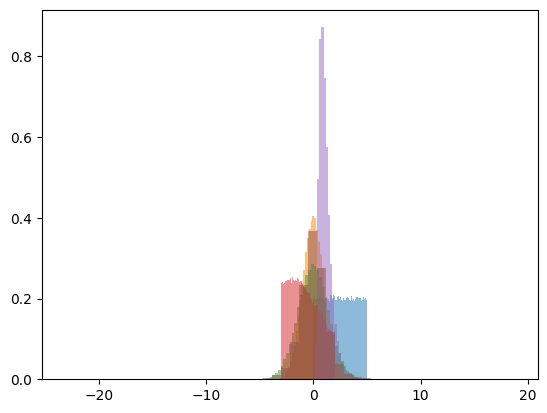

In [236]:
import matplotlib.pyplot as plt

plt.hist(samples, bins=50, density=True, alpha = 0.5)
plt.hist(samples_normal, bins=50, density=True, alpha = 0.5)
plt.hist(samples_multi[:,1], bins=50, density=True, alpha = 0.5)
plt.hist(samples_trunc, bins=50, density=True, alpha = 0.5)
plt.hist(samples_lognormal, bins=50, density=True, alpha = 0.5)
plt.hist(samples_student, bins=50, density=True, alpha = .5)

Running scalability benchmark...
  nsamples = 200
  nsamples = 500
  nsamples = 1000
  nsamples = 10000
  nsamples = 100000
  nsamples = 1000000
  nsamples = 10000000


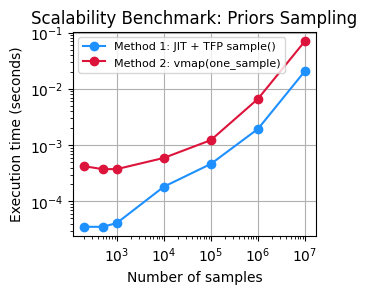

In [171]:
prior = Uniform(parnames=("low", "high"), low=0.0, high=5.0)

# Method 1: JIT-compiled TFP sampler
def sample_prior(key, nsamples):
    return prior.tfp_dist().sample(seed=key, sample_shape=(nsamples,))

run_sampler_jit = jax.jit(sample_prior, static_argnums=1)

# Method 2: elementwise sampling + vmap
@jax.jit
def one_sample(key):
    return prior.sample(key, shape=())

def vectorized_sampler(key, nsamples):
    keys = random.split(key, nsamples)
    return jax.vmap(one_sample)(keys)

# ------------------------------------------------------------
# Accurate benchmarking function
# ------------------------------------------------------------
def benchmark(func, *args):
    # Warmup: compiles JIT
    out = func(*args)
    jax.block_until_ready(out)

    # Timing
    t0 = time.perf_counter()
    out = func(*args)
    jax.block_until_ready(out)
    t1 = time.perf_counter()

    return t1 - t0

# ------------------------------------------------------------
# Sample sizes to test
# ------------------------------------------------------------
sample_sizes = [200, 500, 1000, 10000, 100000, 1000000, 10000000]
t1_times = []
t2_times = []

key0 = random.PRNGKey(0)

print("Running scalability benchmark...")
for n in sample_sizes:
    print(f"  nsamples = {n}")
    t1 = benchmark(run_sampler_jit, key0, n)
    t2 = benchmark(vectorized_sampler, key0, n)
    t1_times.append(t1)
    t2_times.append(t2)

# ------------------------------------------------------------
# Plot results
# ------------------------------------------------------------
plt.figure(figsize=(10/3,3))
plt.plot(sample_sizes, t1_times, "-o", color = "dodgerblue", label="Method 1: JIT + TFP sample()")
plt.plot(sample_sizes, t2_times, "-o", color = 'crimson', label="Method 2: vmap(one_sample)")
plt.xlabel("Number of samples")
plt.ylabel("Execution time (seconds)")
plt.title("Scalability Benchmark: Priors Sampling")
plt.legend(fontsize = 8)
plt.grid(True)
plt.tight_layout()
plt.xscale("log")
plt.yscale("log")
plt.savefig("prior_sampling_benchmark.png", dpi=300)